# Radish Leaf Disease Classification Using a Basic CNN

**Course:** Computer Vision and Pattern Recognition (CVPR)  
**Student:** FAHAD IBNE FIROZ  
**Project type:** Mid Term


## 1. Dataset and experimental caution

The local dataset has five folders/classes: Black leaf spot, Downey mildew, flea beetle, Fresh leaf, and Mosaic virus. The accompanying article reports 2,801 smartphone photographs. Because several photographs were captured from a limited number of physical leaves, an image-level random split may place different views of the same leaf in different subsets when no leaf identifier is available. This possible correlation must be stated as a limitation; the project result is not proof of field-ready diagnosis.

## 2. Imports, device, and reproducibility

In [2]:
import os, sys, json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_recall_fscore_support)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Python:', sys.version)
print('Executable:', sys.executable)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('CUDA runtime:', torch.version.cuda)
    print('GPU:', torch.cuda.get_device_name(0))
print('Using:', DEVICE)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Executable: d:\AI_Project\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA runtime: 12.8
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Using: cuda


## 3. Configuration

In [3]:
DATASET_ROOT = Path(r'D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dataset')
OUTPUT_DIR = Path('outputs'); OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR = Path('checkpoints'); CHECKPOINT_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
NUM_WORKERS = 0       # safe for Windows notebooks
PIN_MEMORY = torch.cuda.is_available()

print('Dataset:', DATASET_ROOT)
print('Exists:', DATASET_ROOT.exists())
if not DATASET_ROOT.exists():
    raise FileNotFoundError('Update DATASET_ROOT to the folder containing the five class folders.')

Dataset: D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dataset
Exists: True


## 4. Inspect and validate the dataset

In [4]:
class_folders = sorted(p for p in DATASET_ROOT.iterdir() if p.is_dir())
print('Class folders:')
for p in class_folders: print(' -', p.name)
if len(class_folders) != 5:
    print('WARNING: expected five immediate class folders.')

valid_ext = {'.jpg','.jpeg','.png','.bmp','.webp'}
records, invalid = [], []
for folder in class_folders:
    for path in sorted(folder.rglob('*')):
        if path.is_file() and path.suffix.lower() in valid_ext:
            try:
                with Image.open(path) as im:
                    w,h = im.size; mode = im.mode
                records.append({'path':str(path),'class':folder.name,
                                'width':w,'height':h,'mode':mode})
            except (UnidentifiedImageError, OSError) as e:
                invalid.append((str(path),str(e)))

df_images = pd.DataFrame(records)
print('Readable images:', len(df_images))
print('Invalid images:', len(invalid))
if len(df_images)==0: raise RuntimeError('No readable images found.')
display(df_images.head())

Class folders:
 - Radish Black leaf spot
 - Radish Downey mildew
 - Radish flea beetle
 - Radish Fresh leaf
 - Radish Mosaic virus
Readable images: 2801
Invalid images: 0


,path,class,width,height,mode
0,D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dat...,Radish Black leaf spot,1280,960,RGB
1,D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dat...,Radish Black leaf spot,1280,960,RGB
2,D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dat...,Radish Black leaf spot,1280,960,RGB
3,D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dat...,Radish Black leaf spot,1280,960,RGB
4,D:\STUDY MATERIAL\CVPR\Project\Radish_Leaf_Dat...,Radish Black leaf spot,1280,960,RGB


,image_count
class,
Radish Black leaf spot,526
Radish Downey mildew,601
Radish Fresh leaf,613
Radish Mosaic virus,548
Radish flea beetle,513


Total: 2801


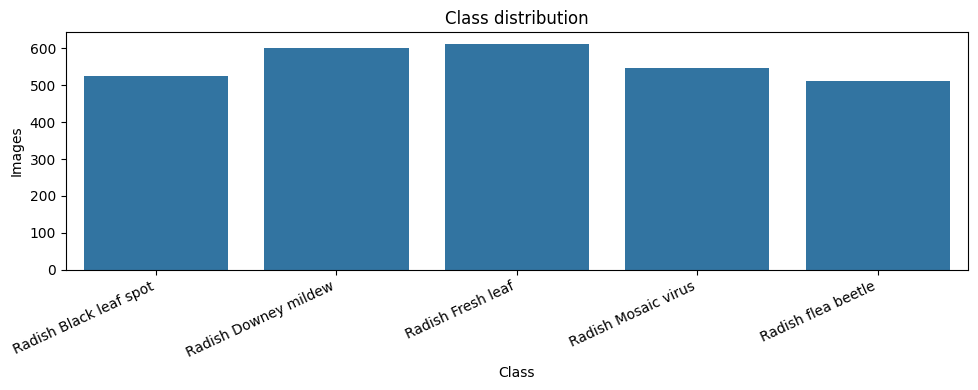

Most common image sizes:


width  height
960    1280      2327
1280   960        471
1058   1280         1
1079   1280         1
1107   1280         1
Name: count, dtype: int64

In [5]:
counts = df_images.groupby('class').size().rename('image_count').to_frame()
display(counts)
print('Total:', counts.image_count.sum())

plt.figure(figsize=(10,4))
sns.barplot(x=counts.index, y=counts.image_count.values)
plt.title('Class distribution'); plt.xlabel('Class'); plt.ylabel('Images')
plt.xticks(rotation=25, ha='right'); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'class_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

print('Most common image sizes:')
display(df_images.groupby(['width','height']).size().sort_values(ascending=False).head(10).rename('count'))

### One sample from each class

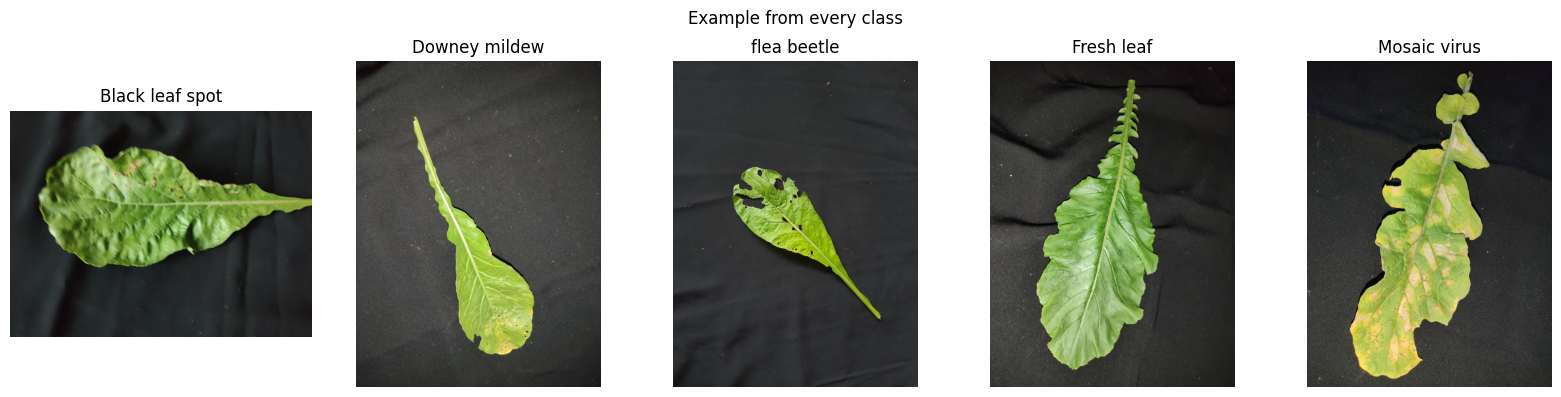

In [6]:
fig, axes = plt.subplots(1,len(class_folders),figsize=(16,4))
for ax, folder in zip(axes,class_folders):
    path = Path(df_images[df_images['class']==folder.name].iloc[0]['path'])
    with Image.open(path) as im: ax.imshow(im.convert('RGB'))
    ax.set_title(folder.name.replace('Radish ','')); ax.axis('off')
plt.suptitle('Example from every class'); plt.tight_layout(); plt.show()

## 5. Fixed stratified split

Use 70% training, 15% validation, and 15% testing. Stratification keeps class proportions similar. The test set is not used to select settings or epochs. The same indices are used by both experiments so the comparison is fair.

In [7]:
index_dataset = datasets.ImageFolder(DATASET_ROOT)
all_paths = np.array([x[0] for x in index_dataset.samples])
all_labels = np.array(index_dataset.targets)
CLASS_NAMES = index_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
indices = np.arange(len(index_dataset))

train_idx, temp_idx = train_test_split(indices,test_size=.30,random_state=SEED,stratify=all_labels)
val_idx, test_idx = train_test_split(temp_idx,test_size=.50,random_state=SEED,
                                     stratify=all_labels[temp_idx])
with open(OUTPUT_DIR/'split_indices.json','w') as f:
    json.dump({'train':train_idx.tolist(),'val':val_idx.tolist(),'test':test_idx.tolist()},f,indent=2)

print('Classes:',CLASS_NAMES)
print('Mapping:',index_dataset.class_to_idx)
print('Train / validation / test:',len(train_idx),len(val_idx),len(test_idx))

def split_counts(idx,name):
    c=Counter(all_labels[idx])
    return pd.DataFrame({'class':CLASS_NAMES,name:[c[i] for i in range(NUM_CLASSES)]}).set_index('class')
display(split_counts(train_idx,'train').join(split_counts(val_idx,'validation')).join(split_counts(test_idx,'test')))

Classes: ['Radish Black leaf spot', 'Radish Downey mildew', 'Radish Fresh leaf', 'Radish Mosaic virus', 'Radish flea beetle']
Mapping: {'Radish Black leaf spot': 0, 'Radish Downey mildew': 1, 'Radish Fresh leaf': 2, 'Radish Mosaic virus': 3, 'Radish flea beetle': 4}
Train / validation / test: 1960 420 421


,train,validation,test
class,,,
Radish Black leaf spot,368,79,79
Radish Downey mildew,421,90,90
Radish Fresh leaf,429,92,92
Radish Mosaic virus,383,82,83
Radish flea beetle,359,77,77


## 6. Transformations

The baseline only resizes and normalizes. The regularized training pipeline creates random variations using cropping, flipping, rotation, and mild color jitter. Color changes are intentionally small because disease symptoms depend partly on leaf color. Validation and test transformations remain deterministic.

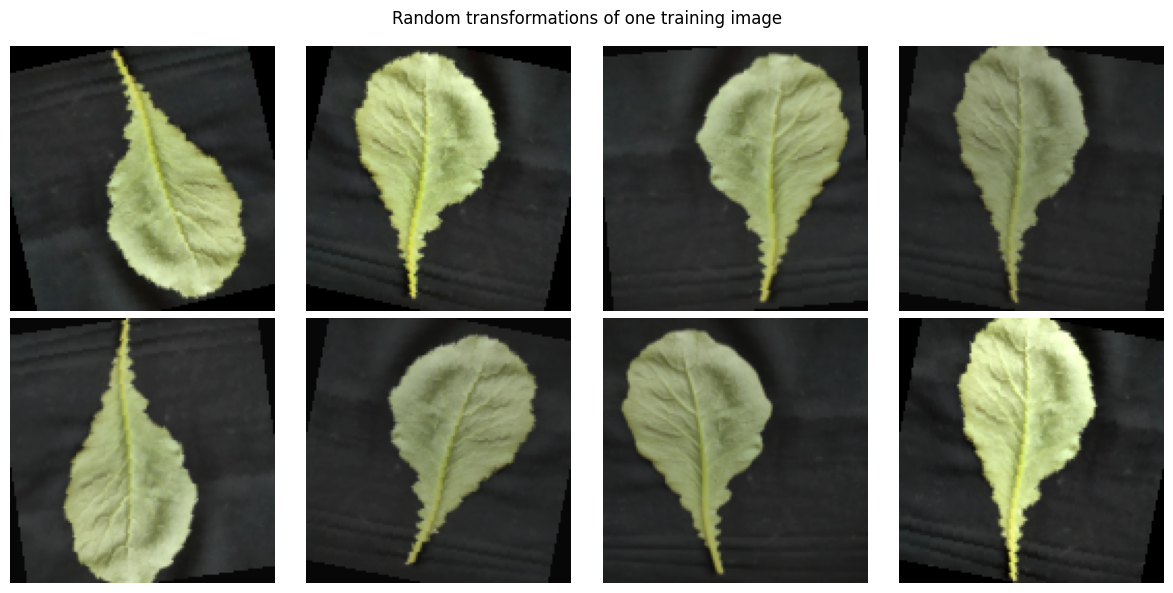

In [8]:
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
baseline_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
regularized_transform = transforms.Compose([
    transforms.Resize((144,144)),
    transforms.RandomResizedCrop((IMAGE_SIZE,IMAGE_SIZE),scale=(.85,1.0)),
    transforms.RandomHorizontalFlip(.5), transforms.RandomVerticalFlip(.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=.15,contrast=.15,saturation=.10),
    transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

def denormalize(x):
    mean=torch.tensor(MEAN).view(3,1,1); std=torch.tensor(STD).view(3,1,1)
    return (x.cpu()*std+mean).clamp(0,1)

with Image.open(all_paths[train_idx[0]]) as im: sample=im.convert('RGB')
fig,axes=plt.subplots(2,4,figsize=(12,6))
for ax in axes.flat:
    x=regularized_transform(sample); ax.imshow(denormalize(x).permute(1,2,0)); ax.axis('off')
plt.suptitle('Random transformations of one training image'); plt.tight_layout();
plt.savefig(OUTPUT_DIR/'augmentation_examples.png',dpi=160,bbox_inches='tight'); plt.show()

## 7. Dataset wrapper and DataLoaders

In [9]:
class ImagePathDataset(Dataset):
    def __init__(self, paths, labels, indices, transform):
        self.paths=paths; self.labels=labels; self.indices=np.asarray(indices); self.transform=transform
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        j=self.indices[i]
        with Image.open(self.paths[j]) as im: image=im.convert('RGB')
        return self.transform(image), int(self.labels[j])

def make_loaders(train_transform):
    train=ImagePathDataset(all_paths,all_labels,train_idx,train_transform)
    val=ImagePathDataset(all_paths,all_labels,val_idx,eval_transform)
    test=ImagePathDataset(all_paths,all_labels,test_idx,eval_transform)
    g=torch.Generator().manual_seed(SEED)
    tr=DataLoader(train,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,
                  pin_memory=PIN_MEMORY,generator=g)
    va=DataLoader(val,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)
    te=DataLoader(test,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)
    return tr,va,te

baseline_train_loader,val_loader,test_loader=make_loaders(baseline_transform)
regularized_train_loader,_,_=make_loaders(regularized_transform)
images,labels=next(iter(baseline_train_loader))
print('Image batch:',images.shape,'Label batch:',labels.shape)

Image batch: torch.Size([32, 3, 128, 128]) Label batch: torch.Size([32])


## 8. Basic CNN from scratch

Each convolution learns visual filters. ReLU adds non-linearity. Max-pooling reduces feature-map size. Adaptive average pooling keeps the dense layer manageable. The final layer returns five raw scores (logits). Do not add softmax before `CrossEntropyLoss`.

In [10]:
class RadishCNN(nn.Module):
    def __init__(self,num_classes=5,dropout_rate=0.0):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4,4)))
        self.classifier=nn.Sequential(
            nn.Flatten(),nn.Linear(128*4*4,256),nn.ReLU(),
            nn.Dropout(dropout_rate),nn.Linear(256,num_classes))
    def forward(self,x): return self.classifier(self.features(x))

model=RadishCNN(NUM_CLASSES,0.0).to(DEVICE)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
with torch.no_grad(): print('Output shape:',model(torch.randn(4,3,IMAGE_SIZE,IMAGE_SIZE,device=DEVICE)).shape)

RadishCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=256, out_features=5, bias=True)
  )
)
Trainable parameters: 619,077
Output shape: torch.Size([4, 5])


## 9. Training functions

In [11]:
def run_epoch(model,loader,criterion,optimizer=None):
    training=optimizer is not None
    model.train() if training else model.eval()
    loss_sum=correct=n=0
    context=torch.enable_grad() if training else torch.no_grad()
    with context:
        for x,y in loader:
            x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
            if training: optimizer.zero_grad(set_to_none=True)
            logits=model(x); loss=criterion(logits,y)
            if training: loss.backward(); optimizer.step()
            bs=y.size(0); loss_sum+=loss.item()*bs
            correct+=(logits.argmax(1)==y).sum().item(); n+=bs
    return loss_sum/n,correct/n

def fit(model,train_loader,val_loader,epochs,path,weight_decay=0.0,patience=None):
    criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=weight_decay)
    h={k:[] for k in ['train_loss','val_loss','train_accuracy','val_accuracy']}
    best=float('inf'); best_epoch=0; stale=0; start=time.time()
    for epoch in range(1,epochs+1):
        tl,ta=run_epoch(model,train_loader,criterion,optimizer)
        vl,va=run_epoch(model,val_loader,criterion)
        h['train_loss'].append(tl); h['val_loss'].append(vl)
        h['train_accuracy'].append(ta); h['val_accuracy'].append(va)
        improved=vl<best
        if improved:
            best=vl; best_epoch=epoch; stale=0; torch.save(model.state_dict(),path)
        else: stale+=1
        print(f'Epoch {epoch:02d}/{epochs} | train loss {tl:.4f} acc {ta:.4f} | '
              f'val loss {vl:.4f} acc {va:.4f}'+(' * best' if improved else ''))
        if patience is not None and stale>=patience:
            print('Early stopping.'); break
    model.load_state_dict(torch.load(path,map_location=DEVICE,weights_only=True))
    print(f'Best epoch: {best_epoch}; best validation loss: {best:.4f}; '
          f'time: {(time.time()-start)/60:.2f} min')
    return h,best_epoch

def plot_history(h,title,filename):
    e=range(1,len(h['train_loss'])+1); fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    ax[0].plot(e,h['train_loss'],label='Training'); ax[0].plot(e,h['val_loss'],label='Validation')
    ax[0].set(title=title+' — loss',xlabel='Epoch',ylabel='Cross-entropy loss'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(e,h['train_accuracy'],label='Training'); ax[1].plot(e,h['val_accuracy'],label='Validation')
    ax[1].set(title=title+' — accuracy',xlabel='Epoch',ylabel='Accuracy'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/filename,dpi=180,bbox_inches='tight'); plt.show()

## 10. Experiment A — baseline

No augmentation, no dropout, no weight decay. A full 30-epoch history is retained so overfitting, if present, is visible. The saved checkpoint is still the epoch with minimum validation loss.

Epoch 01/30 | train loss 1.3663 acc 0.3939 | val loss 0.9698 acc 0.6190 * best
Epoch 02/30 | train loss 0.8346 acc 0.6577 | val loss 0.6711 acc 0.7405 * best
Epoch 03/30 | train loss 0.5257 acc 0.7908 | val loss 0.4695 acc 0.7952 * best
Epoch 04/30 | train loss 0.3678 acc 0.8551 | val loss 0.4456 acc 0.8024 * best
Epoch 05/30 | train loss 0.2497 acc 0.9117 | val loss 0.3543 acc 0.8524 * best
Epoch 06/30 | train loss 0.1858 acc 0.9418 | val loss 0.2815 acc 0.9119 * best
Epoch 07/30 | train loss 0.1424 acc 0.9429 | val loss 0.2260 acc 0.9262 * best
Epoch 08/30 | train loss 0.0947 acc 0.9730 | val loss 0.3065 acc 0.9214
Epoch 09/30 | train loss 0.1068 acc 0.9679 | val loss 0.1545 acc 0.9500 * best
Epoch 10/30 | train loss 0.0358 acc 0.9913 | val loss 0.1818 acc 0.9571
Epoch 11/30 | train loss 0.0473 acc 0.9847 | val loss 0.2591 acc 0.9119
Epoch 12/30 | train loss 0.0361 acc 0.9898 | val loss 0.1261 acc 0.9667 * best
Epoch 13/30 | train loss 0.0072 acc 0.9995 | val loss 0.1084 acc 0.9738 *

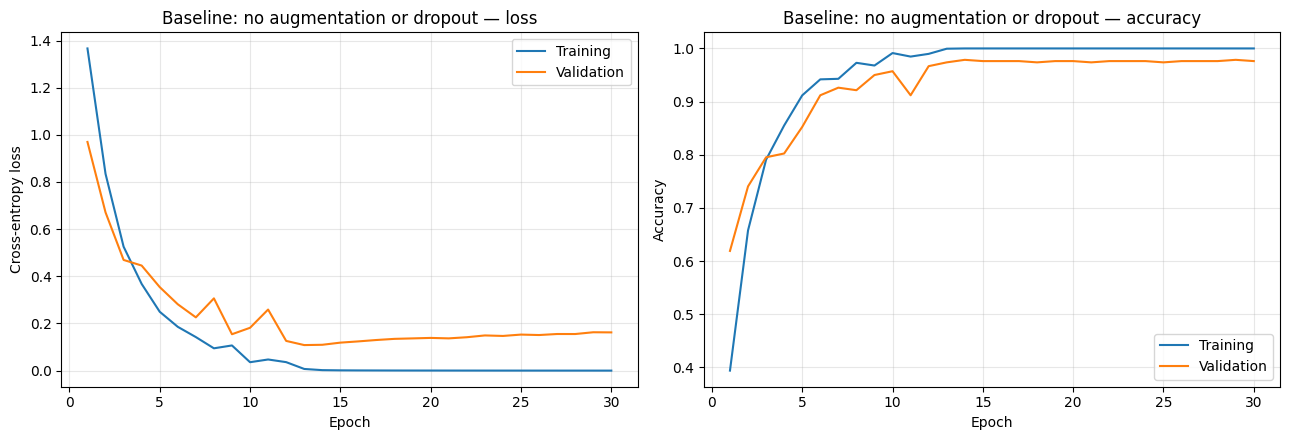

In [12]:
set_seed(); baseline_model=RadishCNN(NUM_CLASSES,dropout_rate=0.0).to(DEVICE)
baseline_history,baseline_best_epoch=fit(
    baseline_model,baseline_train_loader,val_loader,MAX_EPOCHS,
    CHECKPOINT_DIR/'baseline_best.pt',weight_decay=0.0,patience=None)
plot_history(baseline_history,'Baseline: no augmentation or dropout','baseline_curves.png')

**Interpret the baseline:** overfitting is indicated when training loss keeps falling while validation loss rises, and when training accuracy becomes much higher than validation accuracy.

## 11. Experiment B — augmentation and dropout

The same CNN now uses random training transformations, dropout = 0.5, small weight decay, and early stopping. Dropout is automatically disabled during validation/testing by `model.eval()`.

Epoch 01/30 | train loss 1.4962 acc 0.3133 | val loss 1.1289 acc 0.5333 * best
Epoch 02/30 | train loss 1.0898 acc 0.5464 | val loss 0.9212 acc 0.5905 * best
Epoch 03/30 | train loss 0.9877 acc 0.5959 | val loss 0.8672 acc 0.6048 * best
Epoch 04/30 | train loss 0.7918 acc 0.6679 | val loss 0.5750 acc 0.7714 * best
Epoch 05/30 | train loss 0.7010 acc 0.7138 | val loss 0.5436 acc 0.7857 * best
Epoch 06/30 | train loss 0.5631 acc 0.7673 | val loss 0.4779 acc 0.7905 * best
Epoch 07/30 | train loss 0.5500 acc 0.7796 | val loss 0.4385 acc 0.8238 * best
Epoch 08/30 | train loss 0.5066 acc 0.7796 | val loss 0.4279 acc 0.8333 * best
Epoch 09/30 | train loss 0.4417 acc 0.8270 | val loss 0.5338 acc 0.7810
Epoch 10/30 | train loss 0.4442 acc 0.8209 | val loss 0.4285 acc 0.8190
Epoch 11/30 | train loss 0.3693 acc 0.8434 | val loss 0.3955 acc 0.8167 * best
Epoch 12/30 | train loss 0.4187 acc 0.8265 | val loss 0.3309 acc 0.8810 * best
Epoch 13/30 | train loss 0.3586 acc 0.8561 | val loss 0.2990 acc 0

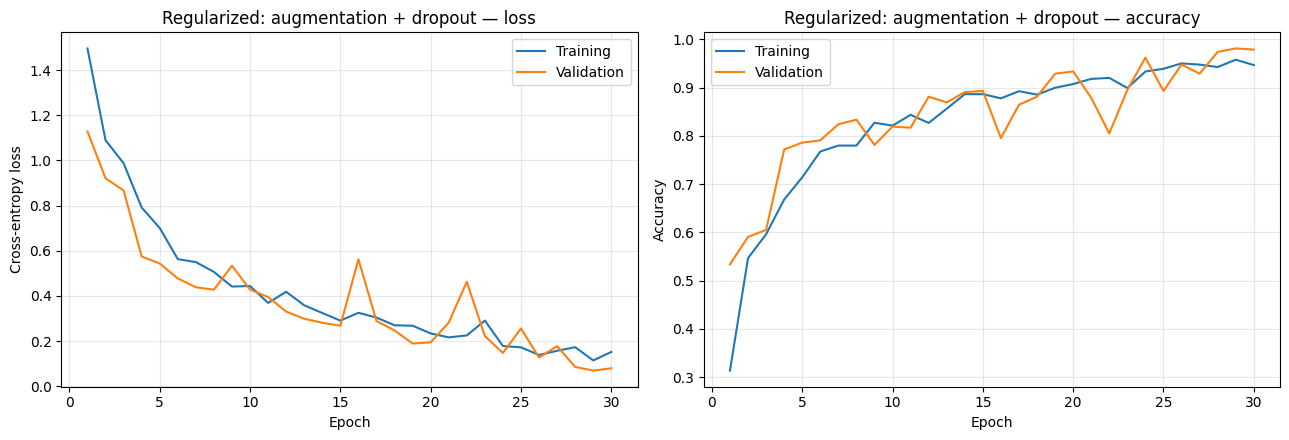

In [13]:
set_seed(); regularized_model=RadishCNN(NUM_CLASSES,dropout_rate=0.5).to(DEVICE)
regularized_history,regularized_best_epoch=fit(
    regularized_model,regularized_train_loader,val_loader,MAX_EPOCHS,
    CHECKPOINT_DIR/'regularized_best.pt',weight_decay=1e-4,patience=6)
plot_history(regularized_history,'Regularized: augmentation + dropout','regularized_curves.png')

## 12. Compare overfitting at the selected epochs

In [14]:
def summary(h,epoch,name):
    i=epoch-1; ta=h['train_accuracy'][i]; va=h['val_accuracy'][i]
    return {'model':name,'selected_epoch':epoch,'train_loss':h['train_loss'][i],
            'validation_loss':h['val_loss'][i],'train_accuracy':ta,
            'validation_accuracy':va,'accuracy_gap':ta-va}
comparison=pd.DataFrame([
    summary(baseline_history,baseline_best_epoch,'Baseline'),
    summary(regularized_history,regularized_best_epoch,'Augmentation + Dropout')]).set_index('model')
display(comparison.style.format({'train_loss':'{:.4f}','validation_loss':'{:.4f}',
 'train_accuracy':'{:.2%}','validation_accuracy':'{:.2%}','accuracy_gap':'{:.2%}'}))
comparison.to_csv(OUTPUT_DIR/'validation_comparison.csv')

,selected_epoch,train_loss,validation_loss,train_accuracy,validation_accuracy,accuracy_gap
model,,,,,,
Baseline,13,0.0072,0.1084,99.95%,97.38%,2.57%
Augmentation + Dropout,29,0.1145,0.0695,95.77%,98.10%,-2.33%


A smaller accuracy gap, a lower/more stable validation loss, and closer training/validation curves are evidence of improved generalization. A regularized model may have lower training accuracy; this can be expected because the goal is not memorization.

## 13. Untouched test evaluation

In [15]:
def predict(model,loader):
    model.eval(); ys=[]; ps=[]; probs=[]; loss_sum=n=0; criterion=nn.CrossEntropyLoss()
    with torch.no_grad():
        for x,y in loader:
            x=x.to(DEVICE); y=y.to(DEVICE); logits=model(x); pr=torch.softmax(logits,1)
            bs=y.size(0); loss_sum+=criterion(logits,y).item()*bs; n+=bs
            ys.extend(y.cpu().numpy()); ps.extend(logits.argmax(1).cpu().numpy()); probs.extend(pr.cpu().numpy())
    return np.array(ys),np.array(ps),np.array(probs),loss_sum/n

def metric_row(name,y,p,loss):
    precision,recall,f1,_=precision_recall_fscore_support(y,p,average='macro',zero_division=0)
    return {'model':name,'test_loss':loss,'test_accuracy':accuracy_score(y,p),
            'macro_precision':precision,'macro_recall':recall,'macro_f1':f1}

by,bp,bprob,bloss=predict(baseline_model,test_loader)
ry,rp,rprob,rloss=predict(regularized_model,test_loader)
results=pd.DataFrame([metric_row('Baseline',by,bp,bloss),
                      metric_row('Augmentation + Dropout',ry,rp,rloss)]).set_index('model')
display(results.style.format({'test_loss':'{:.4f}','test_accuracy':'{:.2%}',
 'macro_precision':'{:.2%}','macro_recall':'{:.2%}','macro_f1':'{:.2%}'}))
results.to_csv(OUTPUT_DIR/'test_results.csv')

,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1
model,,,,,
Baseline,0.1006,98.34%,98.43%,98.27%,98.34%
Augmentation + Dropout,0.1040,98.10%,98.13%,98.04%,98.07%


### Classification report and confusion matrix for the regularized model

,precision,recall,f1-score,support
Radish Black leaf spot,0.950617,0.974684,0.962500,79.000000
Radish Downey mildew,1.000000,1.000000,1.000000,90.000000
Radish Fresh leaf,0.967742,0.978261,0.972973,92.000000
Radish Mosaic virus,0.987952,0.987952,0.987952,83.000000
Radish flea beetle,1.000000,0.961039,0.980132,77.000000
accuracy,0.980998,0.980998,0.980998,0.980998
macro avg,0.981262,0.980387,0.980711,421.000000
weighted avg,0.981309,0.980998,0.981048,421.000000


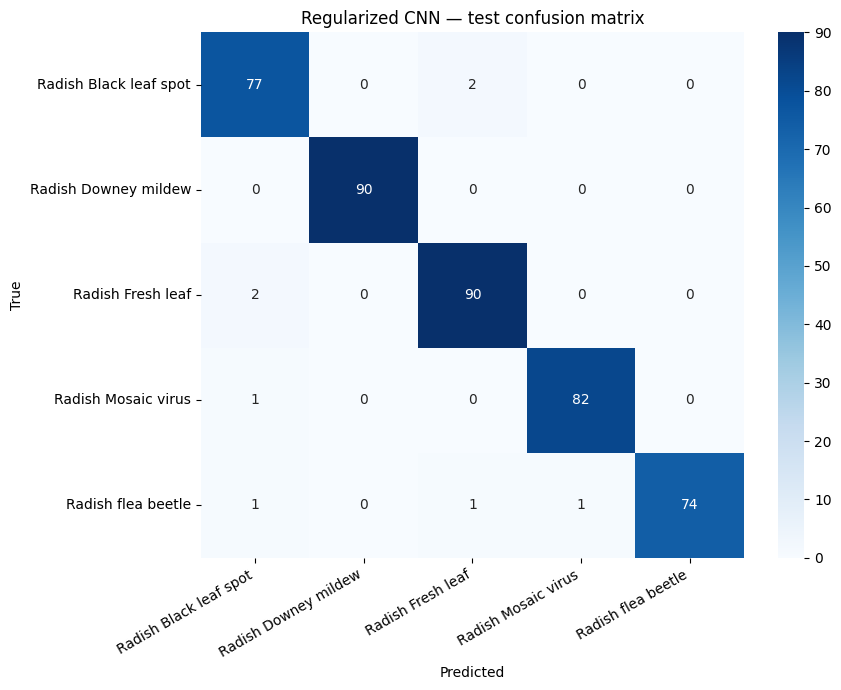

In [16]:
report=pd.DataFrame(classification_report(ry,rp,target_names=CLASS_NAMES,digits=4,
                                           zero_division=0,output_dict=True)).T
display(report); report.to_csv(OUTPUT_DIR/'classification_report.csv')
cm=confusion_matrix(ry,rp)
plt.figure(figsize=(9,7)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
 xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.title('Regularized CNN — test confusion matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30,ha='right'); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'confusion_matrix.png',dpi=180,bbox_inches='tight'); plt.show()

## 14. Misclassified samples and error analysis

Misclassified: 8 of 421


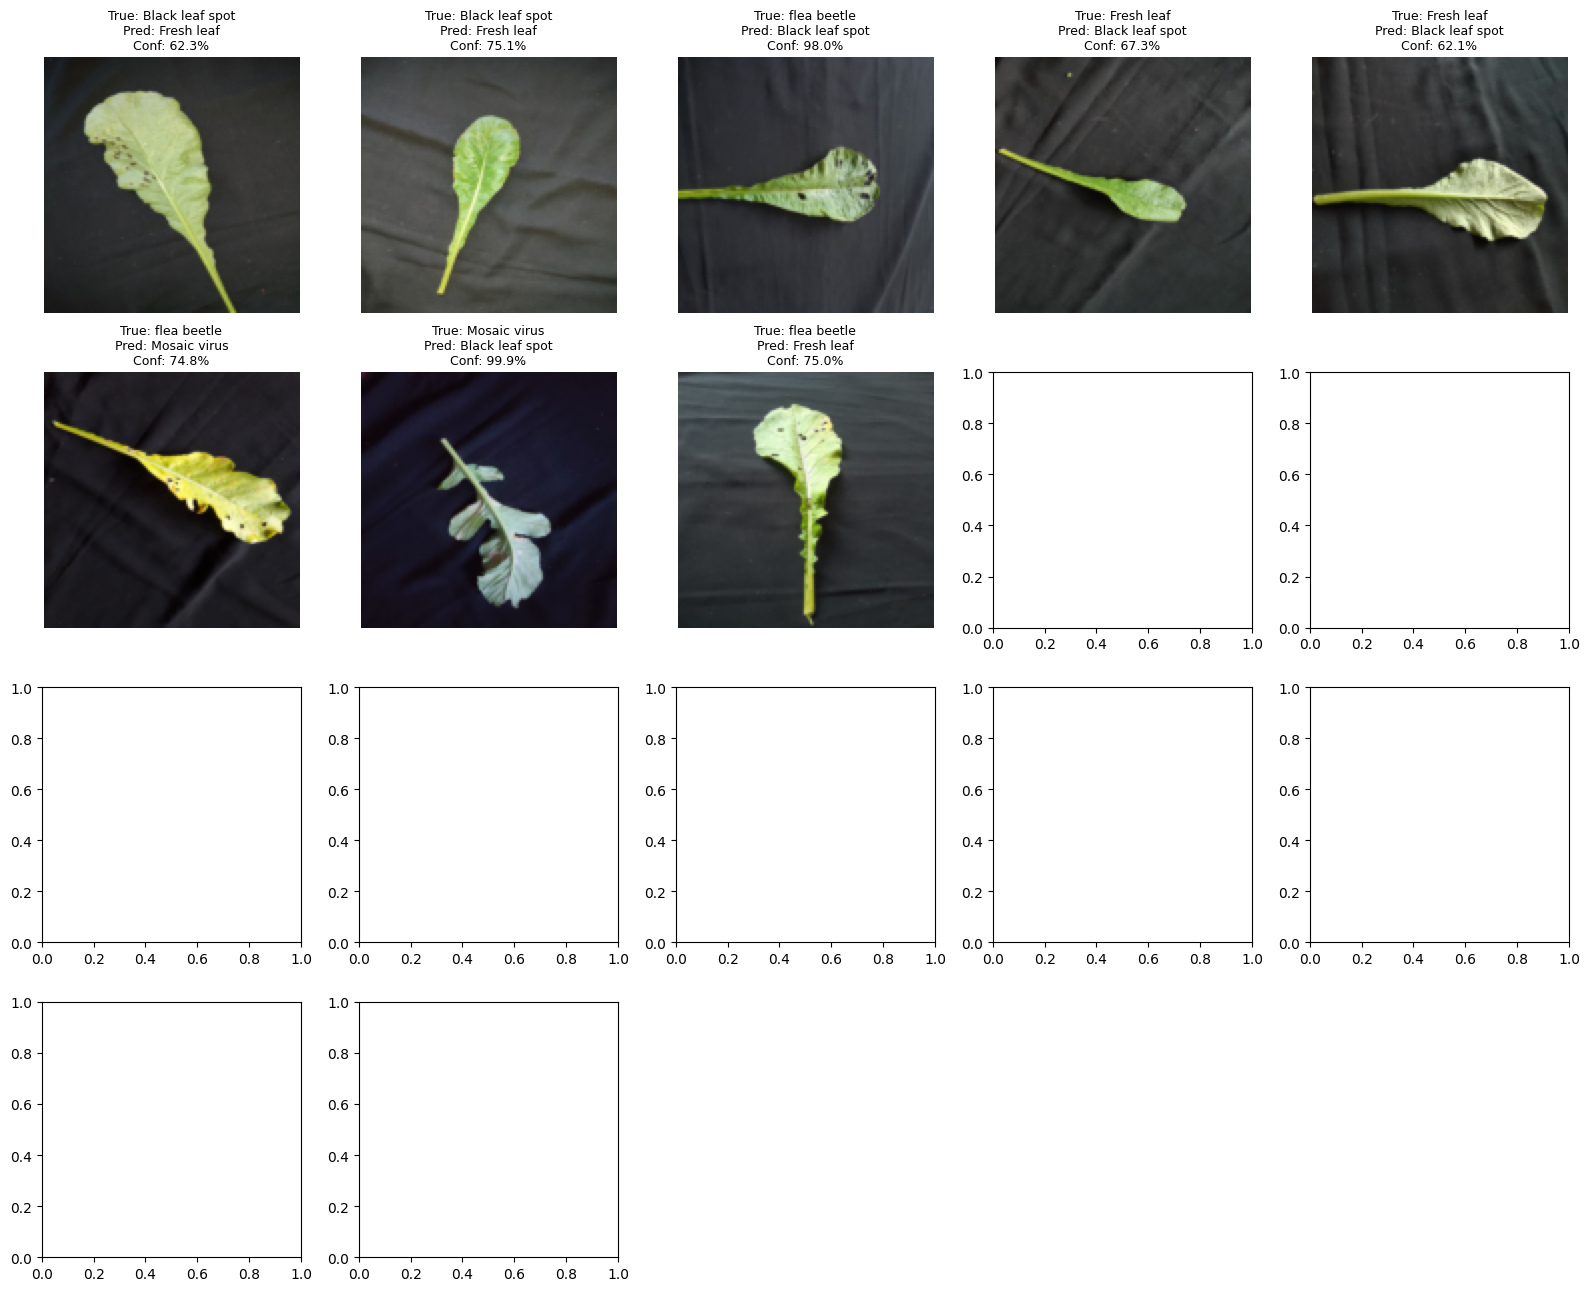

,true,predicted,count
0,Radish Black leaf spot,Radish Fresh leaf,2
1,Radish Fresh leaf,Radish Black leaf spot,2
2,Radish Mosaic virus,Radish Black leaf spot,1
3,Radish flea beetle,Radish Black leaf spot,1
4,Radish flea beetle,Radish Fresh leaf,1
5,Radish flea beetle,Radish Mosaic virus,1


In [19]:
wrong=np.where(ry!=rp)[0]; print('Misclassified:',len(wrong),'of',len(ry))
show=min(20,len(wrong))
if show:
    fig,axes=plt.subplots(4,5,figsize=(16,13)); axes=axes.flat
    for ax,pos in zip(axes,wrong[:show]):
        x,true=test_loader.dataset[pos]; pred=int(rp[pos]); conf=float(rprob[pos,pred])
        ax.imshow(denormalize(x).permute(1,2,0))
        ax.set_title(f"True: {CLASS_NAMES[true].replace('Radish ','')}\n"
                     f"Pred: {CLASS_NAMES[pred].replace('Radish ','')}\nConf: {conf:.1%}",fontsize=9)
        ax.axis('off')
    for ax in list(axes)[show:]: ax.axis('off')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'misclassified.png',dpi=180,bbox_inches='tight'); plt.show()

pairs=[]
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i!=j and cm[i,j]: pairs.append({'true':CLASS_NAMES[i],'predicted':CLASS_NAMES[j],'count':cm[i,j]})
confusion_pairs=pd.DataFrame(pairs).sort_values('count',ascending=False)
display(confusion_pairs.head(10))

## 15. Automatic factual summary

In [18]:
bgap=comparison.loc['Baseline','accuracy_gap']; rgap=comparison.loc['Augmentation + Dropout','accuracy_gap']
print(f'Baseline selected epoch: {baseline_best_epoch}; accuracy gap: {bgap:.2%}')
print(f'Regularized selected epoch: {regularized_best_epoch}; accuracy gap: {rgap:.2%}')
print(f"Baseline test accuracy: {results.loc['Baseline','test_accuracy']:.2%}")
print(f"Regularized test accuracy: {results.loc['Augmentation + Dropout','test_accuracy']:.2%}")
print(f"Regularized macro F1: {results.loc['Augmentation + Dropout','macro_f1']:.2%}")
print('Gap reduced:',rgap<bgap)
print('Regularized test loss lower:',rloss<bloss)

Baseline selected epoch: 13; accuracy gap: 2.57%
Regularized selected epoch: 29; accuracy gap: -2.33%
Baseline test accuracy: 98.34%
Regularized test accuracy: 98.10%
Regularized macro F1: 98.07%
Gap reduced: True
Regularized test loss lower: False


## 16. Final discussion template

Replace the bracketed text after running all cells:

> The baseline CNN was trained without random augmentation or dropout. Its curves showed **[observed pattern]**. At the minimum-validation-loss checkpoint, its training–validation accuracy gap was **[value]**, and test accuracy was **[value]**.
>
> The regularized CNN used random cropping, flips, rotation, mild color jitter, dropout of 0.5, and small weight decay. Its selected accuracy gap was **[value]**, test accuracy was **[value]**, and macro F1 was **[value]**. Compared with the baseline, **[state exactly what improved or did not improve]**. The curves and test metrics therefore provide **[strong/moderate/limited]** evidence that overfitting was controlled.
>
> The confusion matrix showed that **[class pair]** was confused most often. The main limitation is that multiple views came from a small number of physical leaves. Because a leaf-level grouping variable was unavailable, correlated views may occur across subsets and the measured generalization may be optimistic. This is a course-level experiment rather than a field-deployment claim.